# 5 — SQL Analysis

All logic lives in SQL. Python runs queries and plots results.
All queries use `vw_inpatient_analytics` (created in Notebook 3).

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")

DB_PATH = (Path("..") / "data" / "healthcare.db").resolve()
engine  = create_engine(f"sqlite:///{DB_PATH}")

def q(sql):
    return pd.read_sql(text(sql), engine)

q("SELECT COUNT(*) AS total_rows FROM vw_inpatient_analytics")

,total_rows
0,196086


---
## Query 1 — Top Hospitals by Billing Gap (Task 02a)

**Why discharge-weighted average, not a simple average?**

A hospital might have 50 different procedure types in our data. If we just average those 50 billing gap numbers equally, a DRG with 3 patients gets the same weight as one with 800 patients — that would be misleading.

**The fix**: Multiply each row's billing gap by the number of patients in that row, sum them all up, then divide by total patients.

`Weighted Gap = SUM(billing_gap × patients) ÷ SUM(patients)`

This gives the "per-typical-patient" billing gap for each hospital. Busy procedures count more.

In [2]:
df_gap = q("""
WITH hosp AS (
  SELECT facility_id, provider_name, state,
    SUM(tot_dschrgs) AS total_discharges,
    SUM(billing_gap  * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_gap,
    SUM(charge_ratio * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_ratio
  FROM vw_inpatient_analytics
  WHERE avg_mdcr_pymt_amt > 0
  GROUP BY facility_id, provider_name, state
),
ranked AS (
  SELECT *, DENSE_RANK() OVER (ORDER BY wtd_avg_gap DESC) AS gap_rank
  FROM hosp WHERE total_discharges >= 50
)
SELECT * FROM ranked WHERE gap_rank <= 15 ORDER BY gap_rank
""")
df_gap

,facility_id,provider_name,state,total_discharges,wtd_avg_gap,wtd_avg_ratio,gap_rank
0,170201,"Blue Valley Hospital, Inc",KS,73,257389.794520,26.194857,1
1,50441,Stanford Health Care,CA,8606,246759.783988,8.603993,2
2,310092,Capital Health System-Fuld Campus,NJ,1277,217970.854346,19.418767,3
3,50625,Cedars-Sinai Medical Center,CA,18392,214119.621847,11.776577,4
4,50367,Northbay Medical Center,CA,2623,197708.564240,14.229766,5
5,390027,Temple University Hospital,PA,3682,195626.783813,9.051694,6
6,150166,Pinnacle Hospital,IN,193,189957.502589,5.870510,7
7,330234,Westchester Medical Center,NY,4257,171285.914729,7.439856,8
8,390111,Hospital Of Univ Of Pennsylvania,PA,7347,169504.397169,7.813422,9
9,50125,Regional Medical Center Of San Jose,CA,4138,168584.583615,12.006551,10


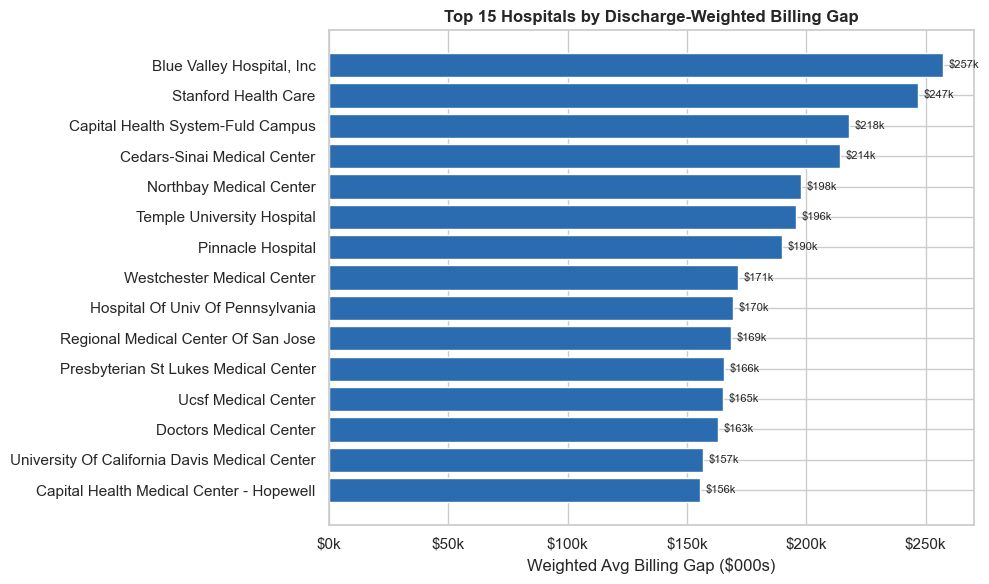

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = df_gap.sort_values("wtd_avg_gap")
bars = ax.barh(plot_df["provider_name"], plot_df["wtd_avg_gap"] / 1000, color="#2b6cb0")
ax.bar_label(bars, labels=[f"${v/1000:.0f}k" for v in plot_df["wtd_avg_gap"]], padding=4, fontsize=8)
ax.set_title("Top 15 Hospitals by Discharge-Weighted Billing Gap", fontweight="bold")
ax.set_xlabel("Weighted Avg Billing Gap ($000s)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "top_hospitals_billing_gap.png", dpi=150, bbox_inches="tight")
plt.show()

### Plain English

A weighted gap of $200,000 means: the typical patient at that hospital was billed $200k more than Medicare paid. These hospitals consistently over-charge across their whole patient mix — not just one expensive procedure.

**Important caveat**: High billing gap does not equal wrongdoing. Hospitals specialising in heart transplants or cancer have genuinely enormous submitted charges. Always check *which procedures* are driving the gap.

---
## Query 2 — Extreme Charge Ratios (Markup Ranking)

Charge ratio is the scale-free version. A ratio of 4× means the hospital billed 4× what Medicare paid — regardless of whether the procedure cost $5k or $500k.

In [4]:
df_ratio = q("""
WITH hosp AS (
  SELECT facility_id, provider_name, state,
    SUM(tot_dschrgs) AS total_discharges,
    SUM(charge_ratio * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_ratio
  FROM vw_inpatient_analytics
  WHERE avg_mdcr_pymt_amt > 0
  GROUP BY facility_id, provider_name, state
),
ranked AS (
  SELECT *, ROW_NUMBER() OVER (ORDER BY wtd_avg_ratio DESC) AS ratio_rank
  FROM hosp WHERE total_discharges >= 50
)
SELECT * FROM ranked WHERE ratio_rank <= 15 ORDER BY ratio_rank
""")
df_ratio

,facility_id,provider_name,state,total_discharges,wtd_avg_ratio,ratio_rank
0,170201,"Blue Valley Hospital, Inc",KS,73,26.194857,1
1,310092,Capital Health System-Fuld Campus,NJ,1277,19.418767,2
2,310044,Capital Health Medical Center - Hopewell,NJ,1452,19.246919,3
3,10040,Gadsden Regional Medical Center,AL,3442,17.522872,4
4,310025,Carepoint Health - Bayonne Medical Center,NJ,1639,17.241419,5
5,10139,Brookwood Baptist Medical Center,AL,2969,16.232901,6
6,310016,Carepoint Health-Christ Hospital,NJ,1248,15.968628,7
7,100126,Palms Of Pasadena Hospital,FL,1371,15.695734,8
8,100264,Oak Hill Hospital,FL,5614,15.611938,9
9,10131,Crestwood Medical Center,AL,3232,15.397097,10


### Plain English

Hospitals on this list charge the highest multiples of Medicare payment across their patient mix. This is often linked to charge-master pricing — a price list hospitals set (sometimes years ago and never updated) that has nothing to do with actual care costs.

---
## Query 3 — Top Paying DRGs using Discharge-Weighted Average

The previous version of this query used `AVG()` — an average of averages, which is inaccurate. The fix: weight by discharge count so high-volume procedures count proportionally more.

In [5]:
df_drg = q("""
WITH drg_pay AS (
  SELECT drg_cd, MAX(drg_desc) AS drg_desc,
    COALESCE(MAX(mdc_name), 'Unknown') AS mdc_name,
    SUM(tot_dschrgs) AS total_discharges,
    SUM(avg_mdcr_pymt_amt * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_payment
  FROM vw_inpatient_analytics
  WHERE avg_mdcr_pymt_amt > 0
  GROUP BY drg_cd
)
SELECT *, RANK() OVER (ORDER BY wtd_avg_payment DESC) AS payment_rank
FROM drg_pay WHERE total_discharges >= 100
ORDER BY payment_rank LIMIT 15
""")
df_drg

,drg_cd,drg_desc,mdc_name,total_discharges,wtd_avg_payment,payment_rank
0,1,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,Nervous System,1957,236868.768012,1
1,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,Nervous System,11714,139677.556172,2
2,14,ALLOGENEIC BONE MARROW TRANSPLANT,Nervous System,590,107990.693220,3
3,215,OTHER HEART ASSIST SYSTEM IMPLANT,Unknown,1625,99545.539692,4
4,5,LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSP...,Unknown,1011,97892.736894,5
5,20,INTRACRANIAL VASCULAR PROCEDURES WITH PRINCIPA...,Nervous System,327,93115.917432,6
6,7,LUNG TRANSPLANT,Nervous System,409,88267.322738,7
7,453,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,Injuries & Poisonings,579,83474.108808,8
8,456,SPINAL FUSION EXCEPT CERVICAL WITH SPINAL CURV...,Unknown,355,83134.101409,9
9,4,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,Unknown,8143,76366.689795,10


### Plain English

The top-paying procedures are almost always organ transplants and critical life support. Heart transplants pay $100k–$250k because they require weeks of ICU, specialist surgical teams, and complex follow-up. These high payments are policy-driven — CMS deliberately reimburses well for these because the alternative (hospitals refusing to perform them) would be catastrophic for patients.

---
## Query 4 — Geographic Analysis: MDC 05 Heart & Circulatory (Task 02c)

MDC 05 = heart attacks, heart failure, bypass surgery, heart failure management.
How does Medicare payment per patient vary across states?

In [6]:
df_geo = q("""
WITH mdc05 AS (
  SELECT state,
    SUM(tot_dschrgs) AS total_discharges,
    SUM(avg_mdcr_pymt_amt * tot_dschrgs) AS total_medicare_payments,
    SUM(avg_mdcr_pymt_amt  * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_payment,
    SUM(avg_submtd_cvrd_chrg * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_charge
  FROM vw_inpatient_analytics
  WHERE mdc = '05' AND state IS NOT NULL AND state != ''
  GROUP BY state
)
SELECT *,
  RANK() OVER (ORDER BY wtd_avg_payment DESC) AS pay_rank,
  AVG(wtd_avg_payment) OVER () AS national_avg_payment
FROM mdc05 ORDER BY wtd_avg_payment DESC
""")
df_geo.head(10)

,state,total_discharges,total_medicare_payments,wtd_avg_payment,wtd_avg_charge,pay_rank,national_avg_payment
0,RI,136,1.749307e+06,12862.551471,34289.654412,1,8684.169207
1,AK,32,4.062830e+05,12696.343750,81885.093750,2,8684.169207
2,CA,3238,3.829931e+07,11828.074737,82867.992588,3,8684.169207
3,MD,1147,1.350166e+07,11771.278989,14447.474281,4,8684.169207
4,MN,1023,1.149935e+07,11240.815249,34624.415445,5,8684.169207
5,OR,238,2.655349e+06,11156.928571,41395.966387,6,8684.169207
6,MA,1479,1.592734e+07,10768.991886,32485.498986,7,8684.169207
7,NH,208,2.176466e+06,10463.778846,41335.778846,8,8684.169207
8,NY,2660,2.735546e+07,10284.007143,50175.505639,9,8684.169207
9,CT,511,5.215152e+06,10205.776908,42894.882583,10,8684.169207


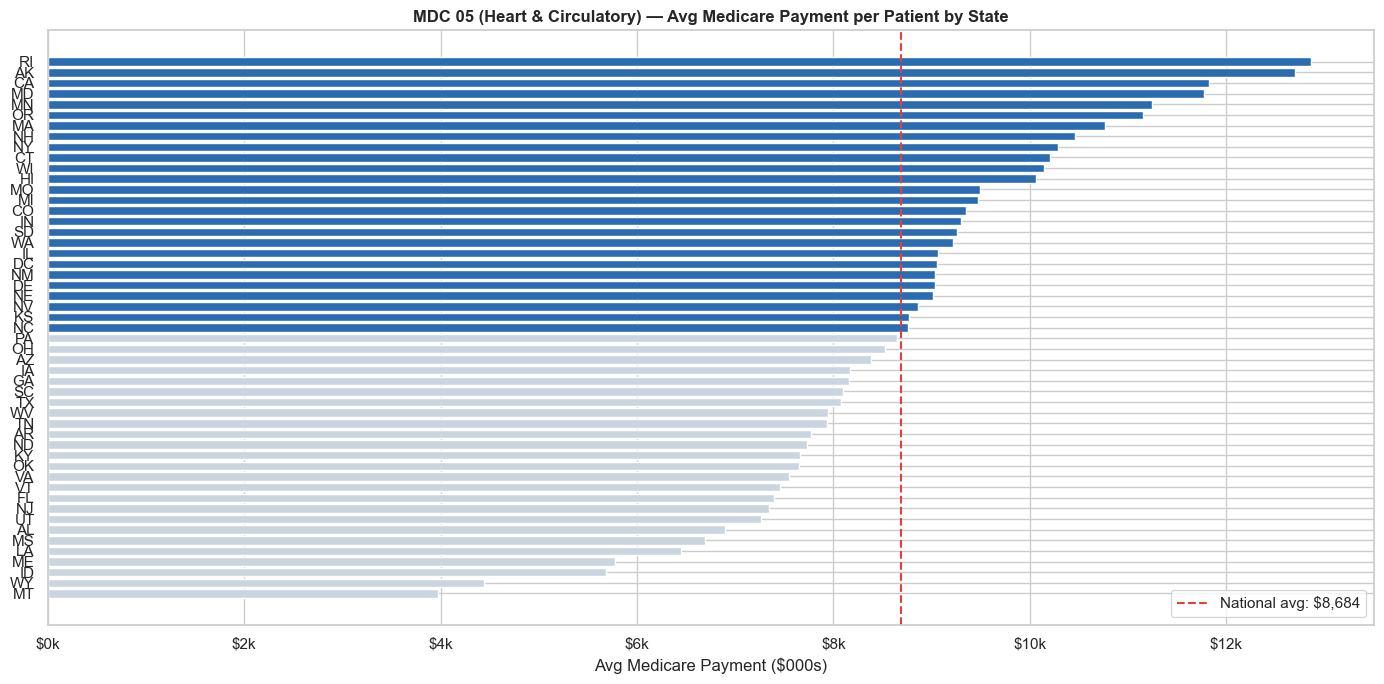

In [7]:
nat_avg = df_geo["national_avg_payment"].iloc[0]
df_geo["above_avg"] = df_geo["wtd_avg_payment"] >= nat_avg

fig, ax = plt.subplots(figsize=(14, 7))
plot_df = df_geo.sort_values("wtd_avg_payment", ascending=True)
colors = ["#2b6cb0" if v else "#cbd5e0" for v in plot_df["above_avg"]]
ax.barh(plot_df["state"], plot_df["wtd_avg_payment"] / 1000, color=colors)
ax.axvline(nat_avg / 1000, color="#e53e3e", linestyle="--", linewidth=1.5,
           label=f"National avg: ${nat_avg:,.0f}")
ax.set_title("MDC 05 (Heart & Circulatory) — Avg Medicare Payment per Patient by State", fontweight="bold")
ax.set_xlabel("Avg Medicare Payment ($000s)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
ax.legend()
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "mdc05_geo_payment.png", dpi=150, bbox_inches="tight")
plt.show()

### Plain English

Medicare payment for heart admissions varies by state because:
- **Wage index**: Medicare adjusts for local labor costs — CA and NY have higher wages so Medicare pays more.
- **Hospital mix**: States with more academic medical centers get higher average payments (they treat more complex cases).
- **DSH bonuses**: States with more low-income patients get extra reimbursement.

The same heart attack patient costs Medicare more in California than in Mississippi — by policy design, not billing aggression.

---
## Query 5 — Ownership Distribution & Billing Behavior (Task 03a)

In [8]:
df_own = q("""
SELECT
  COALESCE(hospital_ownership, 'Unknown') AS hospital_ownership,
  COUNT(DISTINCT facility_id) AS facility_count,
  SUM(tot_dschrgs) AS total_discharges,
  SUM(avg_mdcr_pymt_amt * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_payment,
  SUM(charge_ratio      * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_ratio,
  SUM(billing_gap       * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_gap
FROM vw_inpatient_analytics
WHERE avg_mdcr_pymt_amt > 0
GROUP BY hospital_ownership
ORDER BY facility_count DESC
""")
df_own

,hospital_ownership,facility_count,total_discharges,wtd_avg_payment,wtd_avg_ratio,wtd_avg_gap
0,Voluntary non-profit - Private,1389,4228777,11416.308476,5.013677,43117.249618
1,Proprietary,563,978628,9516.286575,8.367916,65327.980084
2,Unknown,304,204204,9669.003629,5.855866,45513.209482
3,Voluntary non-profit - Other,248,524435,12334.536234,5.177890,50220.406279
4,Government - Hospital District or Authority,219,459316,11011.655381,5.302673,46068.789698
5,Voluntary non-profit - Church,202,597330,11288.369245,4.954626,41686.315141
6,Government - Local,132,190104,10565.839409,4.295554,32381.108861
7,Physician,63,42758,12889.952430,5.118417,51871.062023
8,Government - State,39,150538,16267.477321,4.526369,53610.401799
9,Government - Federal,19,21487,13173.847815,6.578348,73908.496160


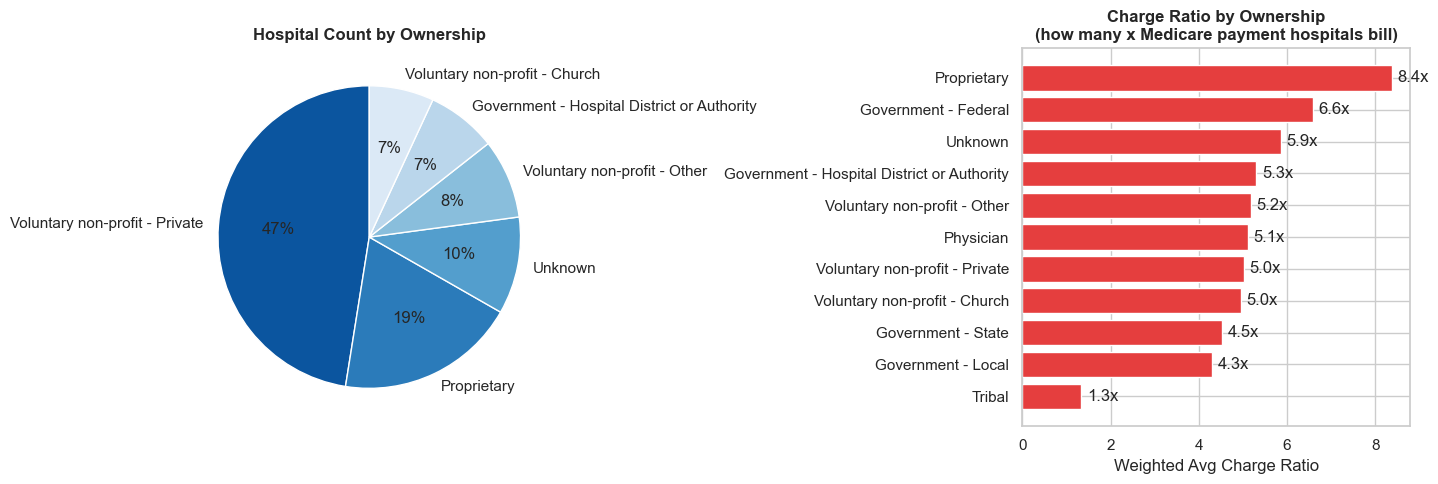

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top6 = df_own.head(6)
axes[0].pie(top6["facility_count"], labels=top6["hospital_ownership"],
            autopct="%1.0f%%", startangle=90,
            colors=sns.color_palette("Blues_r", len(top6)))
axes[0].set_title("Hospital Count by Ownership", fontweight="bold")
plot_df = df_own.sort_values("wtd_avg_ratio", ascending=True)
bars = axes[1].barh(plot_df["hospital_ownership"], plot_df["wtd_avg_ratio"], color="#e53e3e")
axes[1].bar_label(bars, labels=[f"{v:.1f}x" for v in plot_df["wtd_avg_ratio"]], padding=4)
axes[1].set_title("Charge Ratio by Ownership\n(how many x Medicare payment hospitals bill)", fontweight="bold")
axes[1].set_xlabel("Weighted Avg Charge Ratio")
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "ownership_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Plain English

- **Non-profit voluntary hospitals** (~60% of all hospitals) reinvest profits back into care. They charge a lower multiple of Medicare payment.
- **Proprietary (for-profit) hospitals** have shareholder obligations — they charge a higher multiple. This is measurable and consistent.
- **Government hospitals** (VA, local, state) tend to have lower charge ratios — they are not profit-driven.

The for-profit vs non-profit charge ratio difference is real in this data.

---
## Query 6 — MDC Activity Mix by Hospital Type (Task 03b)

Before comparing billing gaps across hospital types, we must check: do different hospital types treat different patients? If yes, billing differences might just be a case-mix effect, not a billing behavior difference.

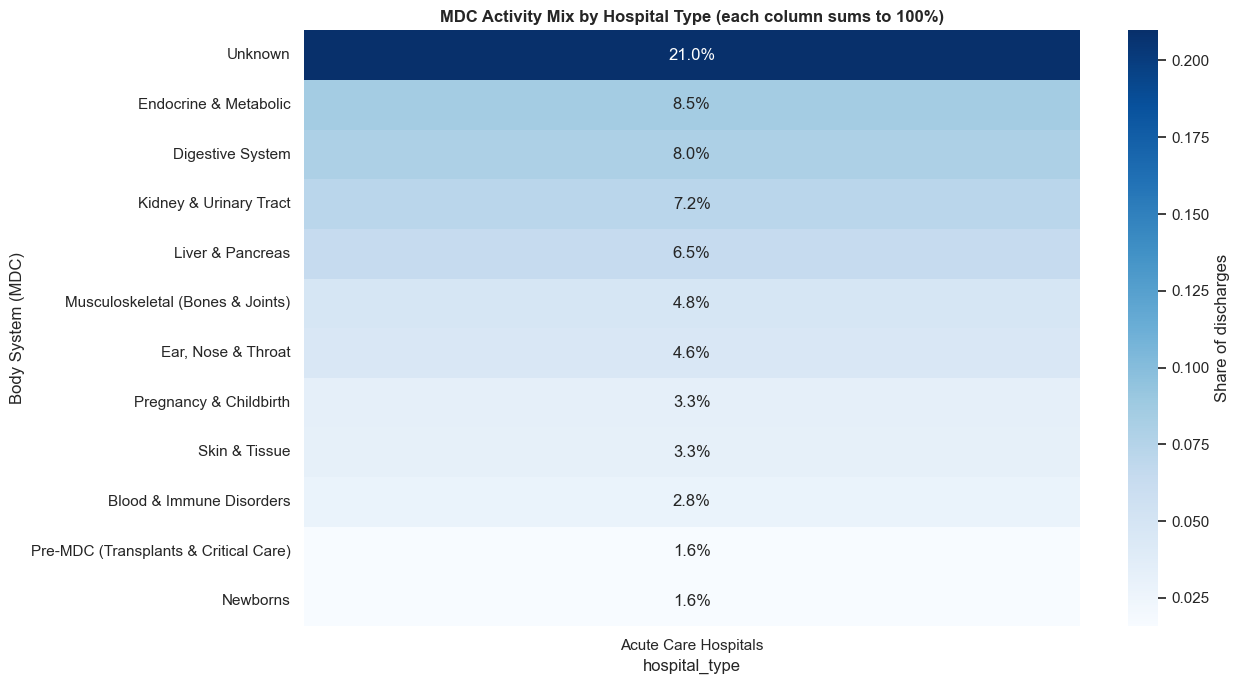

In [10]:
df_mdc_mix = q("""
WITH mdc_by_type AS (
  SELECT COALESCE(hospital_type, 'Unknown') AS hospital_type,
    COALESCE(mdc_name, 'Unknown') AS mdc_name,
    SUM(tot_dschrgs) AS discharges
  FROM vw_inpatient_analytics
  WHERE hospital_type IN ('Acute Care Hospitals','Critical Access Hospitals','Psychiatric','Childrens')
  GROUP BY hospital_type, mdc_name
),
with_share AS (
  SELECT *,
    CAST(discharges AS REAL) / SUM(discharges) OVER (PARTITION BY hospital_type) AS discharge_share
  FROM mdc_by_type
)
SELECT * FROM with_share ORDER BY hospital_type, discharges DESC
""")
pivot = (df_mdc_mix
    .pivot_table(index="mdc_name", columns="hospital_type", values="discharge_share", fill_value=0)
    .sort_values("Acute Care Hospitals", ascending=False).head(12))
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="Blues", ax=ax,
            cbar_kws={"label": "Share of discharges"})
ax.set_title("MDC Activity Mix by Hospital Type (each column sums to 100%)", fontweight="bold")
ax.set_ylabel("Body System (MDC)")
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "mdc_mix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Plain English

Each cell = percentage of that hospital type's patients in that body-system category.

- **Acute Care**: Generalists — spread across many body systems.
- **Critical Access**: Small rural hospitals — more respiratory and general medicine, fewer complex cardiac/surgical cases.
- **Psychiatric**: Almost entirely Mental Health (MDC 19). Expected.
- **Children's hospitals**: Newborns, respiratory, and injuries — completely different from adult hospitals.

> Key insight: You cannot compare billing gaps across hospital types without accounting for their different patient mixes. A Children's hospital having a lower billing gap than an Acute Care hospital is partly because it performs different, simpler procedures.